In [1]:
### Knowledge involved
### 1) perfrom weighted linear regression (WLS) manually 
### 2) Basic visualization with matplotlib.pyplot
### Important note: Learn to check documentation of the package by yourself to learn new functions!
### e.g. for numpy: https://numpy.org/doc/stable/ 
###      for matplotlib: https://matplotlib.org/stable/api/index
###      for sklearn: https://scikit-learn.org/stable/api/index.html

In [2]:
### We aim to perform a 1D regression task with WLS method (2-step procedure). 
###       Input data [1, 2, 3, 4, 5, 6, 7，8]
###       Output data [3.6, 4.8, 6.8, 7.4, 10.5, 9.6, 14.3, 11.8] 
###       The underlying function behind is y = 2+1.5x

In [16]:
### Let's again construct the input and output vectors
import numpy as np
x = np.array([1,2,3,4,5,6,7,8])  ### Input as an array in numpy
y = np.array([3.6, 4.8, 6.8, 7.4, 10.5, 9.6, 14.3, 11.8])

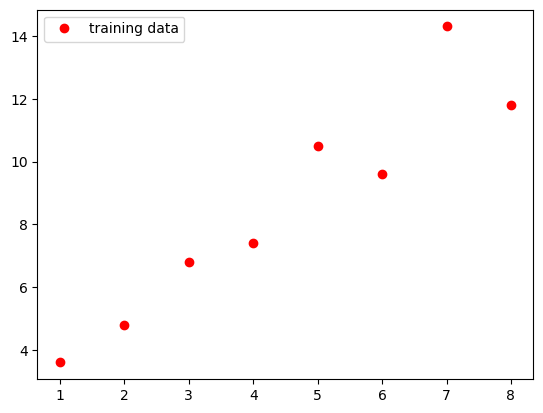

In [23]:
### Now visualize the data and see how it looks like
import matplotlib.pyplot as plt
plt.plot(x,y,'o',color='red',label='training data')
plt.legend()

### As you may observe, it looks quite heteroscedastic 
### The noise seems to increase along x-axis (input)

In [18]:
### Now lets try to use WLS with two-step procedure to address it
### As we did before, we need to construct design matrix X
X = np.hstack((np.ones((x.shape[0],1)),x.reshape(-1,1)))

### Now lets use OLS to compute the coefficients of the model 
w_ols = np.linalg.inv(X.T@X)@X.T@y

In [19]:
### Now we need to compute the residual epsilon_i = y_i - w^T*x_i
### We have y vector ready but we need to make model prediction
r = y - X@w_ols

In [20]:
### Lets construct the weights 'd', as shown in 2-step procedure 
### d_i = 1/(sigma_i)^2
### np.squeeze() compress the array if column or row equals to 1
### e.g. v.shape = (8,1), np.squeeze(v).shape = (8,)
d = np.squeeze(1/np.square(r))

### Construct the weight matrix 
### np.diag(a) returns you a diagonal matrix with vector 'a' on diagonal 
D = np.diag(d)

### Now lets use WLS to compute the coefficients of the model 
w_wls = np.linalg.inv(X.T@D@X)@X.T@D@y

In [21]:
### Lets compare the result of OLS and WLS(2-step prodecure) 
### Create test input points ranging from 0 to 9 with 200 points in between
x_test = np.linspace(0,9,200)

### again, form design matrix X_test
X_test = np.hstack((np.ones((x_test.shape[0],1)),x_test.reshape(-1,1))) 

y_test_ols = X_test@w_ols
y_test_wls = X_test@w_wls

Ground truth: y = 2+1.5x
OLS estimates: y = 2.3642857142857183+1.3857142857142855x
WLS estimates: y = 2.217019487772281+1.403872083236686x


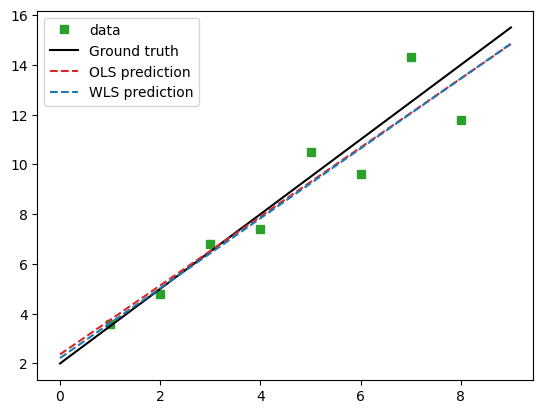

In [22]:
plt.plot(x,y,'s',color='tab:green',label='data') ### plot data
plt.plot(x_test,2+1.5*x_test,'-',color='black',label='Ground truth')
plt.plot(x_test,y_test_ols,'--',color='tab:red',label='OLS prediction')
plt.plot(x_test,y_test_wls,'--',color='tab:blue',label='WLS prediction')
plt.legend() ### show label

### As you can see, the results are close but not exactly same
### after 2-step precedure, the WLS result is better
print('Ground truth: y = 2+1.5x')
print('OLS estimates: y = '+str(w_ols[0])+'+'+str(w_ols[1])+'x')
print('WLS estimates: y = '+str(w_wls[0])+'+'+str(w_wls[1])+'x')